**AUTOREGRESSION_WALK-FORWARD-VALIDATION**

In [13]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('daily-min-temperatures.csv', header = 0, parse_dates=[0])
df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [18]:
train , test = df.Temp[0:df.shape[0]-7], df.Temp[df.shape[0]-7:]
train.head()

0    20.7
1    17.9
2    18.8
3    14.6
4    15.8
Name: Temp, dtype: float64

In [19]:
from statsmodels.tsa.ar_model import AutoReg
data = train
prediction=[]
for t in test:
    model = AutoReg(data, lags=25)
    model_fit = model.fit()
    y = model_fit.predict(start = len(data), end = len(train)+len(test)-1)
    print(y.values[0])
    prediction.append(y.values[0])
    data=np.append(data,t)
    data=pd.Series(data)





11.88082214518343
13.691393368882538
14.388201864241669
13.515749041561227
13.392658359050074
13.474995165343703
14.666930749171039


In [20]:
prediction

[np.float64(11.88082214518343),
 np.float64(13.691393368882538),
 np.float64(14.388201864241669),
 np.float64(13.515749041561227),
 np.float64(13.392658359050074),
 np.float64(13.474995165343703),
 np.float64(14.666930749171039)]

In [21]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(test.values, prediction)
mse

1.394702183702189

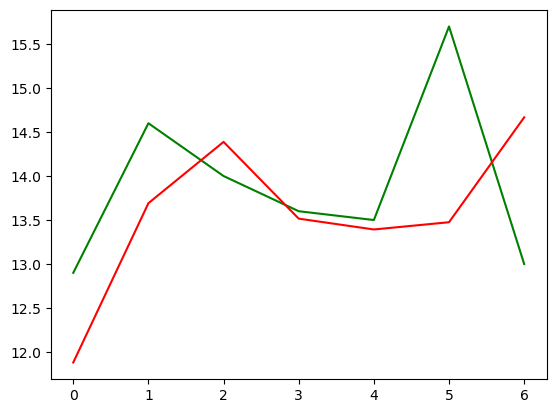

In [22]:
from matplotlib import pyplot
pyplot.plot(test.values, color='green')
pyplot.plot(prediction, color='red')